In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/pokemon.csv")

## Data Cleaning & Exploration

In [ ]:
# First few rows
print(df.head())

# Summary info
print(df.info())

# Statistics for numeric columns
print(df.describe())

                     abilities  against_bug  against_dark  against_dragon  \
0  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
1  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
2  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
3     ['Blaze', 'Solar Power']          0.5           1.0             1.0   
4     ['Blaze', 'Solar Power']          0.5           1.0             1.0   

   against_electric  against_fairy  against_fight  against_fire  \
0               0.5            0.5            0.5           2.0   
1               0.5            0.5            0.5           2.0   
2               0.5            0.5            0.5           2.0   
3               1.0            0.5            1.0           0.5   
4               1.0            0.5            1.0           0.5   

   against_flying  against_ghost  ...  percentage_male  pokedex_number  \
0             2.0            1.0  ...             88.1      

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
print(df.columns)

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='object')


In [ ]:
# Check for missing values
print(df.isnull().sum())

#Handle missing values
df["type2"] = df["type2"].fillna("None")
df["weight_kg"] = df["weight_kg"].fillna("None")
df["height_m"] = df["height_m"].fillna("None")
df["percentage_male"] = df["percentage_male"].fillna("None")

print(df["type2"])
print(df["weight_kg"])


abilities            0
against_bug          0
against_dark         0
against_dragon       0
against_electric     0
against_fairy        0
against_fight        0
against_fire         0
against_flying       0
against_ghost        0
against_grass        0
against_ground       0
against_ice          0
against_normal       0
against_poison       0
against_psychic      0
against_rock         0
against_steel        0
against_water        0
attack               0
base_egg_steps       0
base_happiness       0
base_total           0
capture_rate         0
classfication        0
defense              0
experience_growth    0
height_m             0
hp                   0
japanese_name        0
name                 0
percentage_male      0
pokedex_number       0
sp_attack            0
sp_defense           0
speed                0
type1                0
type2                0
weight_kg            0
generation           0
is_legendary         0
dtype: int64
0      poison
1      poison
2      poison
3 

In [ ]:
# Ensure numeric columns are numeric
numeric_cols = ["hp","attack","defense","sp_attack","sp_defense","speed","generation","is_legendary"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
print(df[numeric_cols])

      hp  attack  defense  sp_attack  sp_defense  speed  generation  \
0     45      49       49         65          65     45           1   
1     60      62       63         80          80     60           1   
2     80     100      123        122         120     80           1   
3     39      52       43         60          50     65           1   
4     58      64       58         80          65     80           1   
..   ...     ...      ...        ...         ...    ...         ...   
796   97     101      103        107         101     61           7   
797   59     181      131         59          31    109           7   
798  223     101       53         97          53     43           7   
799   97     107      101        127          89     79           7   
800   80      95      115        130         115     65           7   

     is_legendary  
0               0  
1               0  
2               0  
3               0  
4               0  
..            ...  
796    

## Creating new columns


In [ ]:
df["efficiency"] = (df["base_total"] / df["speed"]).round(1)
print(df["efficiency"])

df["offense"] = df["attack"] + df["sp_attack"]
df["defense"] = df["defense"] + df["sp_defense"]
print(df[["name","offense","defense"]])

0       7.1
1       6.8
2       7.8
3       4.8
4       5.1
       ... 
796     9.3
797     5.2
798    13.3
799     7.6
800     9.2
Name: efficiency, Length: 801, dtype: float64
           name  offense  defense
0     Bulbasaur      114      114
1       Ivysaur      142      143
2      Venusaur      222      243
3    Charmander      112       93
4    Charmeleon      144      123
..          ...      ...      ...
796  Celesteela      208      204
797     Kartana      240      162
798    Guzzlord      198      106
799    Necrozma      234      190
800    Magearna      225      230

[801 rows x 3 columns]


In [ ]:
# Legendary status boolean column
df["is_legendary"] = df["is_legendary"].astype(bool)
print(df[["name","is_legendary"]])

           name  is_legendary
0     Bulbasaur         False
1       Ivysaur         False
2      Venusaur         False
3    Charmander         False
4    Charmeleon         False
..          ...           ...
796  Celesteela          True
797     Kartana          True
798    Guzzlord          True
799    Necrozma          True
800    Magearna          True

[801 rows x 2 columns]


## Correlation analysis

In [ ]:
# Compute correlation matrix for numeric stats
numeric_cols = ["hp","attack","defense","sp_attack","sp_defense","speed","generation","is_legendary"]
correlation_matrix = df[numeric_cols].corr().round(1)
print(correlation_matrix)

               hp  attack  defense  sp_attack  sp_defense  speed  generation  \
hp            1.0     0.4      0.3        0.4         0.4    0.2         0.1   
attack        0.4     1.0      0.4        0.4         0.3    0.4         0.1   
defense       0.3     0.4      1.0        0.4         0.9    0.1         0.1   
sp_attack     0.4     0.4      0.4        1.0         0.5    0.4         0.1   
sp_defense    0.4     0.3      0.9        0.5         1.0    0.2         0.0   
speed         0.2     0.4      0.1        0.4         0.2    1.0        -0.0   
generation    0.1     0.1      0.1        0.1         0.0   -0.0         1.0   
is_legendary  0.3     0.3      0.3        0.4         0.3    0.3         0.1   

              is_legendary  
hp                     0.3  
attack                 0.3  
defense                0.3  
sp_attack              0.4  
sp_defense             0.3  
speed                  0.3  
generation             0.1  
is_legendary           1.0  


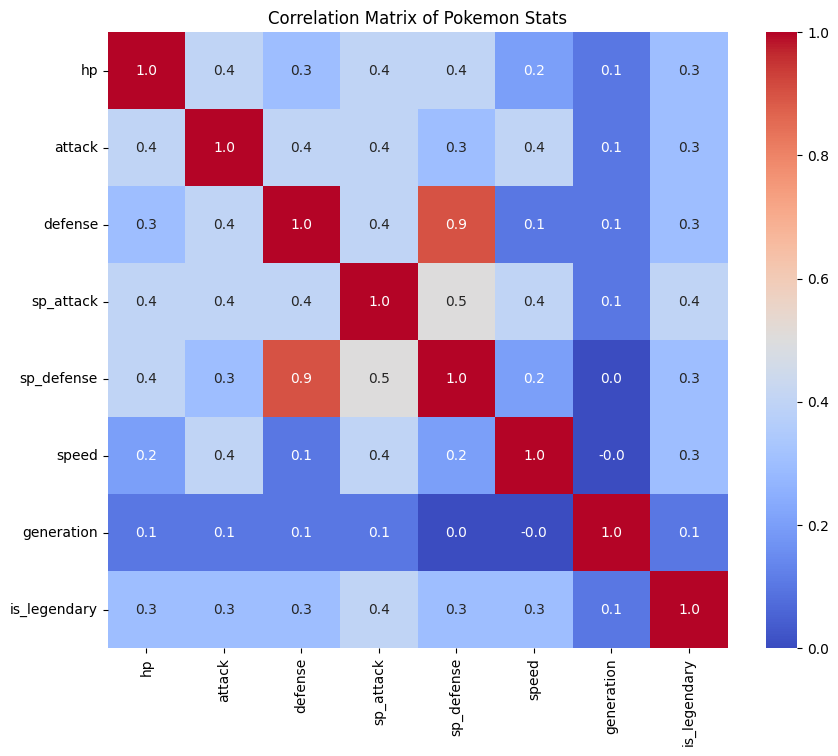

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Matrix of Pokemon Stats")
plt.show()

## Regression Analysis

In [ ]:
# Predict total from individual stats or custom metrics like efficiency.
# Purpose: Quantify contribution of each stat to total strength.

# Features and target
X = df[["hp","attack","defense","sp_attack","sp_defense","speed"]]
y = df["base_total"]

# Train-test split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

print("R^2 score:", model.score(X_test, y_test))
print("Coefficients:", dict(zip(X.columns,model.coef_)))

R^2 score: 1.0
Coefficients: {'hp': np.float64(1.0000000000000016), 'attack': np.float64(1.0000000000000002), 'defense': np.float64(1.0000000000000004), 'sp_attack': np.float64(1.0000000000000002), 'sp_defense': np.float64(5.551115123125783e-16), 'speed': np.float64(1.0)}


## Comparing legendary vs non-legendary Pokemon

                hp  attack  defense  sp_attack  sp_defense  speed  generation  \
is_legendary                                                                    
False         66.4    74.8    138.4       67.2        67.9   63.5         3.6   
True          95.4   109.4    201.3      113.8       101.9   95.4         4.6   

              is_legendary  
is_legendary                
False                  0.0  
True                   1.0  
is_legendary
False    731
True      70
Name: count, dtype: int64


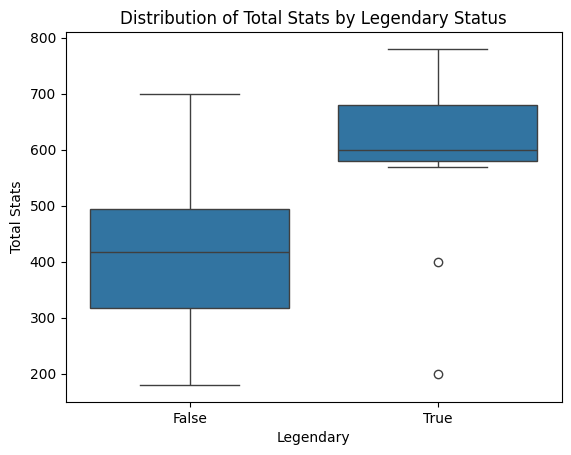

In [ ]:
# Average stats by legendary status
avg_by_legendary = df.groupby("is_legendary")[numeric_cols].mean().round(1)
print(avg_by_legendary)

# Count of legendary vs non-legendary pokemon
legendary_counts = df["is_legendary"].value_counts()
print(legendary_counts)

# Visual comparison (boxplot of total stats)
sns.boxplot(x="is_legendary", y="base_total", data=df)
plt.title("Distribution of Total Stats by Legendary Status")
plt.xlabel("Legendary")
plt.ylabel("Total Stats")

plt.show()

## Ranking Pokemon by Stats

In [ ]:
# Rank by total stats
top_total = df.sort_values("base_total",ascending=False).head(10)
print(top_total[["name","base_total"]])

         name  base_total
149    Mewtwo         780
383  Rayquaza         780
381    Kyogre         770
382   Groudon         770
492    Arceus         720
717   Zygarde         708
380    Latios         700
645    Kyurem         700
379    Latias         700
444  Garchomp         700
